# Part 1: Dogs vs Cats Under Tile Orders
This notebook trains three image-classification architecture families on Dogs vs Cats.
It evaluates how fixed tile-wise tile permutations affect validation accuracy.
Results are aggregated by tile count and plotted as accuracy vs number of tiles.


## Setup

### Global / External Imports
Import third-party libraries used only for notebook orchestration and display.


most basic imports

In [1]:
from pathlib import Path
import importlib
import os
import sys


### Local Imports
Import project modules. Part 1 orchestration lives in this notebook; reusable training, preprocessing, and evaluation helpers stay in `src`.


prep for local imports

In [2]:
from pathlib import Path
import importlib
import importlib.util

_REQUIRED_PROJECT_FILES = (
    Path('src/__init__.py'),
    Path('src/utils/notebook_setup.py'),
    Path('src/evaluation/experiment_results.py'),
)

_CANDIDATE_PROJECT_ROOTS = (
    Path('/content/drive/MyDrive/MLDS_Final_Project'),
    Path('/content/MLDS_Final_Project'),
    Path('/content/drive/MyDrive/Colab Notebooks/MLDS_Final_Project'),
)


def _safe_resolve(path):
    try:
        return Path(path).resolve()
    except OSError:
        return None


def _safe_exists(path):
    try:
        return Path(path).exists()
    except OSError:
        return False


def _safe_cwd():
    try:
        return Path.cwd().resolve()
    except OSError:
        fallback = Path('/content')
        return fallback if _safe_exists(fallback) else Path.home()


def _safe_glob(path, pattern):
    try:
        return list(path.glob(pattern))
    except OSError:
        return []


def _path_looks_like_project_root(path):
    try:
        return all((path / required).is_file() for required in _REQUIRED_PROJECT_FILES)
    except OSError:
        return False


def _candidate_project_roots():
    current = _safe_cwd()
    candidates = [current, *current.parents, *_CANDIDATE_PROJECT_ROOTS]
    my_drive = Path('/content/drive/MyDrive')
    if _safe_exists(my_drive):
        candidates.extend(_safe_glob(my_drive, 'MLDS_Final_Project'))
        candidates.extend(_safe_glob(my_drive, '*/MLDS_Final_Project'))
    return candidates


def _find_project_root():
    seen = set()
    for candidate in _candidate_project_roots():
        candidate = _safe_resolve(candidate)
        if candidate is None or candidate in seen:
            continue
        seen.add(candidate)
        if _path_looks_like_project_root(candidate):
            return candidate
    return None


def _mount_colab_drive_if_available():
    try:
        from google.colab import drive  # type: ignore
    except ImportError:
        return
    drive.mount('/content/drive', force_remount=True)


_PROJECT_ROOT = _find_project_root()
if _PROJECT_ROOT is None:
    _mount_colab_drive_if_available()
    _PROJECT_ROOT = _find_project_root()

if _PROJECT_ROOT is None:
    raise ModuleNotFoundError(
        'Could not find the full MLDS_Final_Project repo. Expected '
        'src/__init__.py, src/utils/notebook_setup.py, and '
        'src/evaluation/experiment_results.py. In Colab, upload or clone '
        'the full repo, or place it at /content/drive/MyDrive/MLDS_Final_Project.'
    )

_COLAB_UTILS_PATH = _PROJECT_ROOT / 'src' / 'utils' / 'colab.py'
_COLAB_SPEC = importlib.util.spec_from_file_location('_mlds_colab_bootstrap', _COLAB_UTILS_PATH)
if _COLAB_SPEC is None or _COLAB_SPEC.loader is None:
    raise ImportError(f'Could not load Colab bootstrap helpers from {_COLAB_UTILS_PATH}')
_colab_bootstrap = importlib.util.module_from_spec(_COLAB_SPEC)
_COLAB_SPEC.loader.exec_module(_colab_bootstrap)

ROOT = _colab_bootstrap.bootstrap_notebook_runtime(_PROJECT_ROOT, force_remount=False)
notebook_setup = importlib.import_module('src.utils.notebook_setup')
ROOT


/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.10.18
Package versions:
  numpy: 1.26.4
  pandas: 2.1.4
  scipy: 1.11.4
  scikit-learn: 1.7.2
  torch: 2.5.1
  torchvision: 0.20.1
  timm: 1.0.26
  pyyaml: 6.0.3
torch.cuda.is_available(): False
Project root: /Users/royrubin/Documents/GitHub/MLDS_Final_Project


PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project')

make local imports

In [3]:
import pandas as pd
from IPython.core.display import Image
from IPython.display import display

import src.evaluation.experiment_results as experiment_results

experiment_results = importlib.reload(experiment_results)
from src.utils.reproducibility import seed_everything  # noqa: E402


### Setup configs

In [4]:
import src.models.factory as model_factory
import src.training.trainer as trainer_module
import src.utils.plotting as plotting
import src.experiments.part1 as part1_experiments

model_factory = importlib.reload(model_factory)
trainer_module = importlib.reload(trainer_module)
plotting = importlib.reload(plotting)
part1_experiments = importlib.reload(part1_experiments)

load_experiment_samples = experiment_results.load_experiment_samples
stage_configured_colab_data_dir = experiment_results.stage_configured_colab_data_dir
plot_accuracy_vs_tiles = experiment_results.plot_accuracy_vs_tiles
experiment_intermediate_figure_path = experiment_results.experiment_intermediate_figure_path
save_aggregated_accuracy = experiment_results.save_aggregated_accuracy
save_rows = experiment_results.save_rows
train_model_on_tile_permutation_records = part1_experiments.train_model_on_tile_permutation_records
plot_tile_permutation_samples = plotting.plot_tile_permutation_samples
from src.preprocessing.samples import class_counts  # noqa: E402
from src.preprocessing.tile_permutations import build_tile_permutation_records, matrix_to_flat_order, tile_permutation_to_jsonable  # noqa: E402
from src.utils.io import save_csv  # noqa: E402


In [5]:
part1_setup = notebook_setup.setup_part1_config()
configs = part1_setup.configs
configs.num_tile_permutations = 3  # Keep easy, medium, and hard in local sample/table output.
configs.stage_colab_data_to_local_disk = True  # Set False on Colab to read directly from Drive instead of copying to /content.
device = part1_setup.device


Selected device: cpu
Python: 3.10.18
Package versions:
  numpy: 1.26.4
  pandas: 2.1.4
  scipy: 1.11.4
  scikit-learn: 1.7.2
  torch: 2.5.1
  torchvision: 0.20.1
  timm: 1.0.26
  pyyaml: 6.0.3
torch.cuda.is_available(): False
Selected device: cpu


CVExperimentConfig(part='part1', config_name='part1', device='auto', deterministic=False, root_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project', data_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/data/dogs-vs-cats/train', outputs_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs', results_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results', figures_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures', sample_data=True, sample_limit=256, val_fraction=0.2, test_fraction=0.0, image_size=224, batch_size=16, num_workers=2, num_classes=2, model_names=['resnet18', 'deit_tiny', 'mlp_mixer_base'], pretrained=True, freeze_backbone=True, tiles_per_side_values=[1, 4, 7, 10], num_tile_permutations=3, epochs=1, learning_rate=0.0003, optimizer='adamw', weight_decay=0.0001, use_amp=False, seed=42, max_threads=4, using_google_colab=False, plot_samples=True, stage_colab_data_to_local_disk=True, colab_local_data_dir='/content/M

In [ ]:
print(configs)


In [6]:
%%time
configs.data_dir = stage_configured_colab_data_dir(configs)
print(f'Active data_dir: {configs.data_dir}')


Active data_dir: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/data/dogs-vs-cats/train
CPU times: user 292 µs, sys: 98 µs, total: 390 µs
Wall time: 447 µs


Local runs use a balanced 256-image subset and 5 training epochs. With `val_fraction=0.2`, the validation split is large enough for accuracy to move in smaller steps than the old 6-image smoke-test split. In aggregated results, `final_epoch` means the metric from the last epoch, and `best_epoch` means the best validation score observed during training.

### make installations before final external imports

In [7]:
# Dependencies are installed during the setup/bootstrap cell above when running in Colab.
print('Dependency setup is complete.')


Dependency setup is complete.


### final imports (after doing pip install if working on colab)

In [8]:
import json
import random
from IPython.core.display import Image
from IPython.display import display
import pandas as pd
import numpy as np
import torch


## Experiments

### Experiment helpers
Shared helpers are kept in `src/evaluation/experiment_results.py`; notebook-specific helpers stay here.

In [9]:
# Part 1 output paths are prepared by notebook_setup.setup_part1_config().


### Setup Exp

In [10]:
# 4. Reproducibility (important for multiple notebooks
random.seed(configs.seed)
np.random.seed(configs.seed)
torch.manual_seed(configs.seed)
torch.set_num_threads(configs.max_threads)  # avoid contention across notebooks

In [11]:
output_paths = part1_setup.output_paths
output_paths


{'raw_results': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_raw_results.csv',
 'aggregated_results': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_aggregated_results.csv',
 'figure': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/part1_accuracy_vs_tiles.png',
 'intermediate_figures_dir': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/intermediate',
 'tile_permutations': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_tile_permutations.csv',
 'accuracy_plot': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/part1_accuracy_vs_tiles.png'}

### Data Loading
Discover the configured Dogs vs Cats split before training.


In [12]:
train_samples, validation_samples, test_samples = load_experiment_samples(config=configs, seed=configs.seed)
print(f'Train samples: {len(train_samples)}')
print(f'Validation samples: {len(validation_samples)}')
print(f'Test samples: {len(test_samples)}')
print('Train class counts:', class_counts(samples=train_samples))
print('Validation class counts:', class_counts(samples=validation_samples))
print('Test class counts:', class_counts(samples=test_samples))

Train samples: 204
Validation samples: 52
Test samples: 0
Train class counts: {'cat': 102, 'dog': 102}
Validation class counts: {'cat': 26, 'dog': 26}
Test class counts: {'cat': 0, 'dog': 0}


### Experiments - Run Baselines
Run the configured baseline grid/model/tile permutation sweep. Re-run this cell to regenerate Part 1 outputs.


Saved 12 tile permutation records


,grid,num_tiles,difficulty,tile_permutation_id,flat_order_preview
0,1x1 / None,1,easy,1,None
1,1x1 / None,1,medium,2,None
2,1x1 / None,1,hard,3,None
3,4x4,16,easy,1,"[1, 0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
4,4x4,16,medium,2,"[6, 5, 7, 4, 9, 10, 11, 8, 13, 14, 2, 12]"
5,4x4,16,hard,3,"[14, 9, 8, 13, 6, 5, 4, 12, 3, 1, 0, 2]"
6,7x7,49,easy,1,"[1, 0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
7,7x7,49,medium,2,"[24, 9, 10, 47, 17, 13, 7, 15, 16, 12, 18, 19]"
8,7x7,49,hard,3,"[17, 28, 13, 25, 22, 10, 21, 16, 7, 1, 20, 11]"
9,10x10,100,easy,1,"[1, 0, 2, 3, 4, 5, 7, 6, 8, 9, 10, 11]"


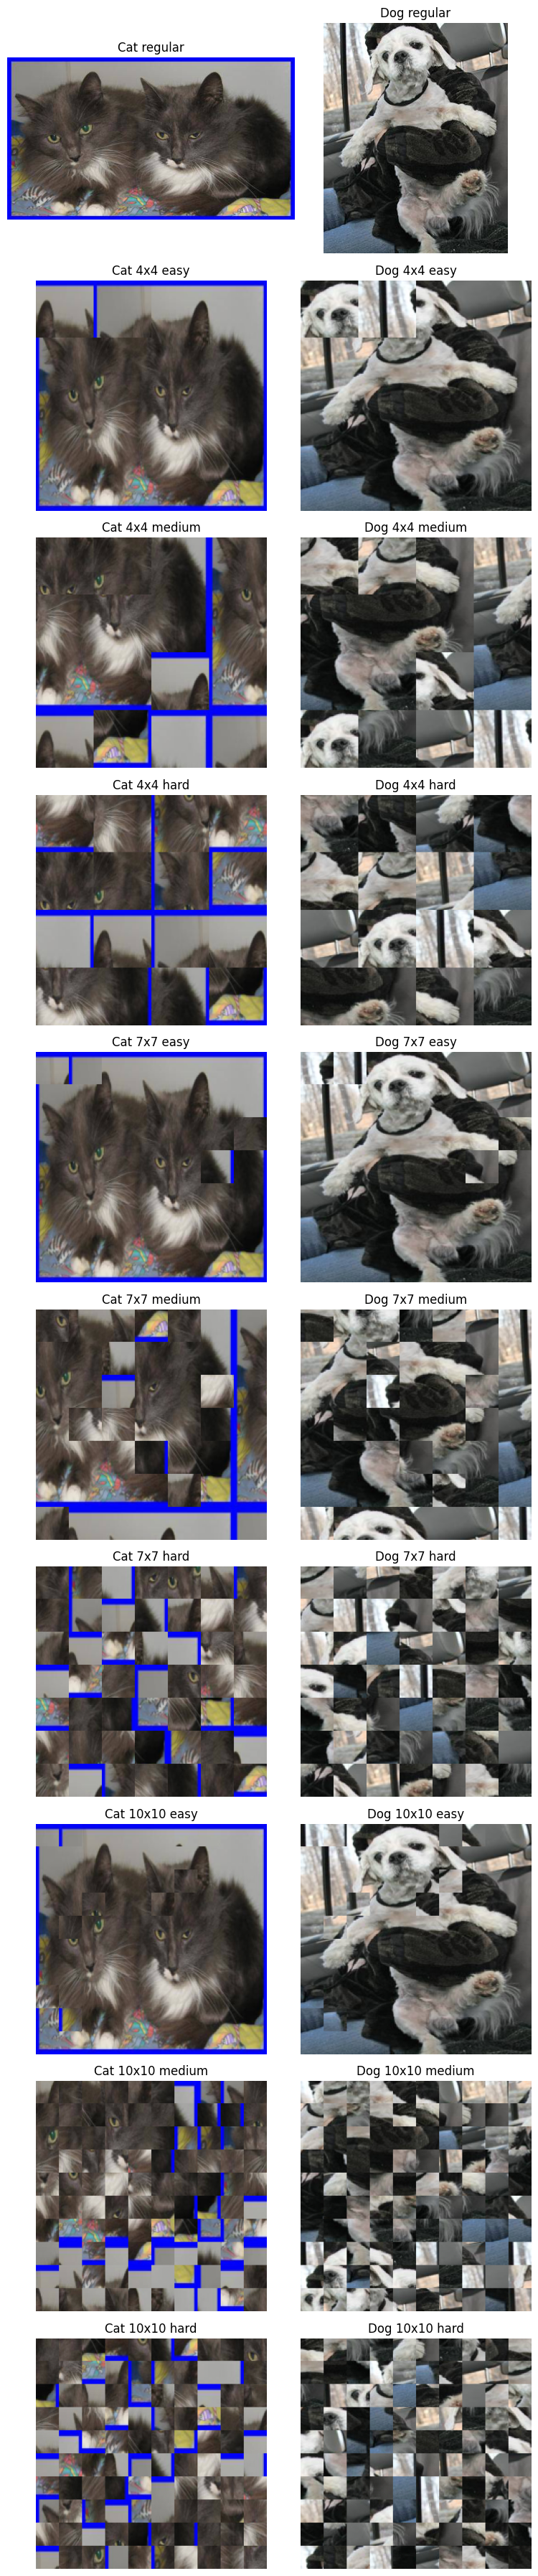

In [13]:
# Build and save tile permutation records
tile_permutation_records = build_tile_permutation_records(
    tiles_per_side_values=configs.tiles_per_side_values,
    num_tile_permutations=configs.num_tile_permutations,
    seed=configs.seed,
    include_baseline=True,
)
tile_permutation_rows = [
    record.__dict__ | {'tile_permutation': json.dumps(tile_permutation_to_jsonable(record.tile_permutation))}
    for record in tile_permutation_records
]
save_csv(data=tile_permutation_rows, path=output_paths['tile_permutations'])
print(f"Saved {len(tile_permutation_records)} tile permutation records")

permutation_examples = []
for record in tile_permutation_records:
    grid_label = '1x1 / None' if record.tiles_per_side is None else f'{record.tiles_per_side}x{record.tiles_per_side}'
    flat_order = None if record.tile_permutation is None else matrix_to_flat_order(record.tile_permutation)
    permutation_examples.append(
        {
            'grid': grid_label,
            'num_tiles': 1 if record.tiles_per_side is None else record.tiles_per_side * record.tiles_per_side,
            'difficulty': record.tile_permutation_name,
            'tile_permutation_id': record.tile_permutation_id,
            'flat_order_preview': 'None' if flat_order is None else flat_order[: min(12, len(flat_order))],
        }
    )
display(pd.DataFrame(permutation_examples))

if configs.plot_samples:
    import matplotlib.pyplot as plt

    plot_tile_permutation_samples(
        samples=train_samples,
        tile_permutation_records=tile_permutation_records,
        image_size=configs.image_size,
        samples_per_class=1,
        max_records=sum(1 for record in tile_permutation_records if record.tile_permutation is not None),
    )
    plt.show()


In [14]:
# Setup reproducibility and load data
seed = configs.seed
seed_everything(seed=seed, deterministic=configs.deterministic)
# Data already loaded above
print(f"Loaded {len(train_samples)} train, {len(validation_samples)} val samples")

Loaded 204 train, 52 val samples


In [15]:
# Prepare shared result accumulation across model runs
all_rows = []
run_id = configs.config_name

### Train Lightweight Model Trio
Train the configured pretrained trio: ResNet-18, DeiT-Tiny, and MLP-Mixer Small.

Saved 12 pending row(s) for model 'resnet18'.

[1/12]
model=resnet18, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


resnet18 1x1 easy permutation: 100%|██████████| 1/1 [00:34<00:00, 34.10s/epoch, best_val_accuracy=0.558, stage=standard, train_accuracy=0.407, train_loss=0.829, val_accuracy=0.558, val_loss=0.703]


Current run runtime: 44s
Total training runtime: 44s

[2/12]
model=resnet18, tiles_per_side=None, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


resnet18 1x1 medium permutation: 100%|██████████| 1/1 [00:34<00:00, 34.70s/epoch, best_val_accuracy=0.885, stage=standard, train_accuracy=0.647, train_loss=0.631, val_accuracy=0.885, val_loss=0.452]


Current run runtime: 45s
Total training runtime: 1m 49s

[3/12]
model=resnet18, tiles_per_side=None, tile_permutation_id=3, tile_permutation_name=hard, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


...

Current run runtime: 40s
Total training runtime: 10m 38s

[11/12]
model=resnet18, tiles_per_side=10, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 230, 230)


resnet18 10x10 medium permutation: 100%|██████████| 1/1 [00:27<00:00, 27.02s/epoch, best_val_accuracy=0.577, stage=standard, train_accuracy=0.544, train_loss=0.707, val_accuracy=0.577, val_loss=0.684]


Current run runtime: 33s
Total training runtime: 11m 31s

[12/12]
model=resnet18, tiles_per_side=10, tile_permutation_id=3, tile_permutation_name=hard, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 230, 230)


resnet18 10x10 hard permutation: 100%|██████████| 1/1 [00:27<00:00, 27.34s/epoch, best_val_accuracy=0.519, stage=standard, train_accuracy=0.559, train_loss=0.694, val_accuracy=0.519, val_loss=0.744]


Current run runtime: 33s
Total training runtime: 12m 24s
Saved intermediate model plot: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/intermediate/part1_accuracy_vs_tiles_resnet18.png
Completed training resnet18 with 12 runs


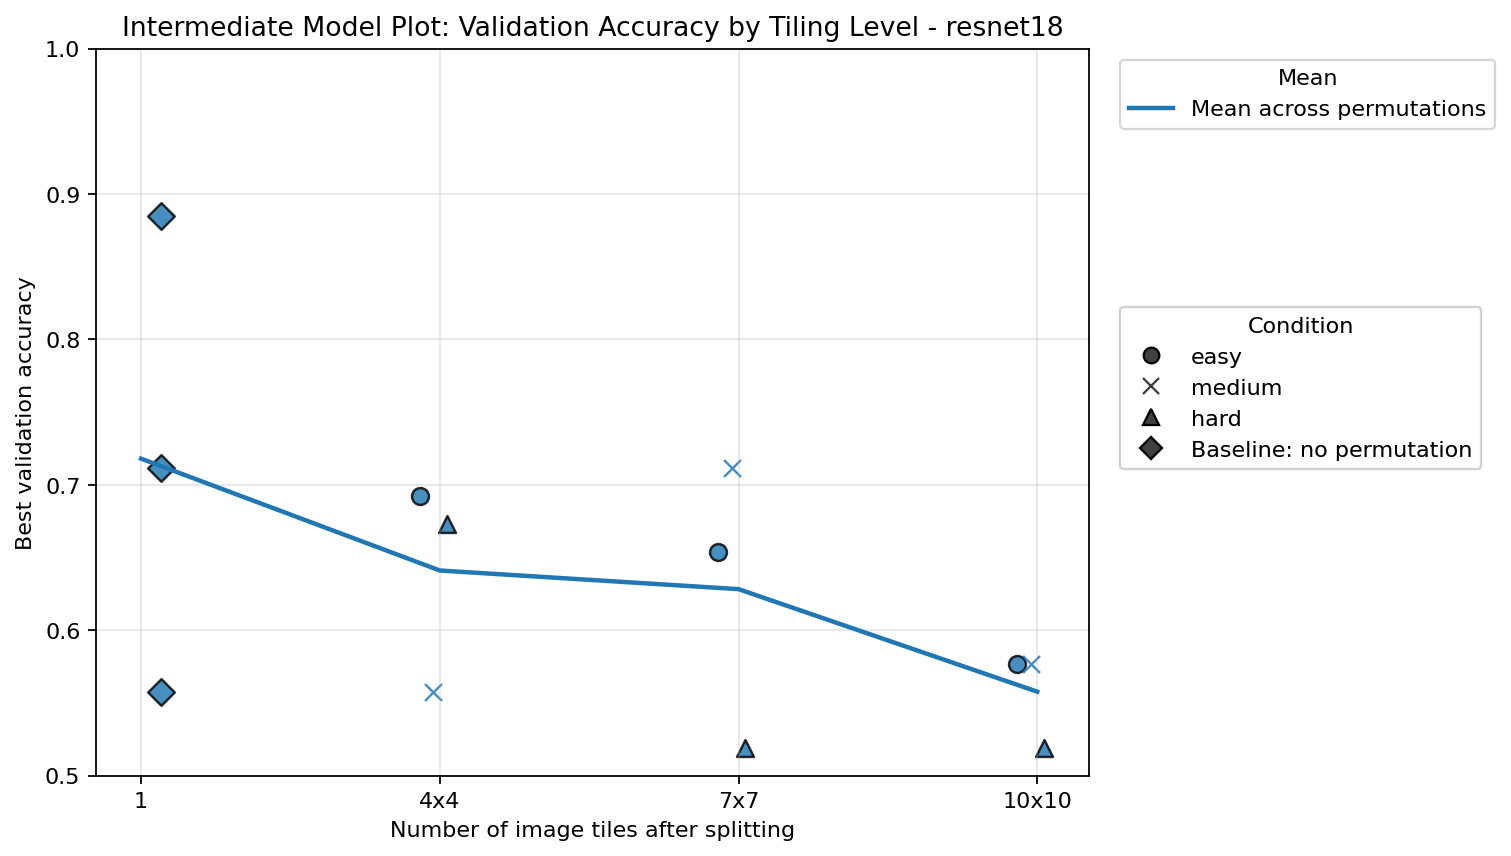

Saved 12 pending row(s) for model 'deit_tiny'.

[1/12]
model=deit_tiny, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'deit_tiny'...


Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=deit_tiny, total_params=5,524,802, trainable_params=386, optimizer_params=386, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


deit_tiny 1x1 easy permutation: 100%|██████████| 1/1 [00:36<00:00, 36.36s/epoch, best_val_accuracy=0.827, stage=standard, train_accuracy=0.554, train_loss=0.671, val_accuracy=0.827, val_loss=0.501]


Current run runtime: 44s
Total training runtime: 44s

[2/12]
model=deit_tiny, tiles_per_side=None, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'deit_tiny'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=deit_tiny, total_params=5,524,802, trainable_params=386, optimizer_params=386, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


deit_tiny 1x1 medium permutation: 100%|██████████| 1/1 [00:31<00:00, 31.70s/epoch, best_val_accuracy=0.808, stage=standard, train_accuracy=0.392, train_loss=0.771, val_accuracy=0.808, val_loss=0.566]


...

Current run runtime: 36s
Total training runtime: 9m 03s

[11/12]
model=deit_tiny, tiles_per_side=10, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'deit_tiny'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=deit_tiny, total_params=5,524,802, trainable_params=386, optimizer_params=386, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


deit_tiny 10x10 medium permutation: 100%|██████████| 1/1 [00:29<00:00, 29.43s/epoch, best_val_accuracy=0.577, stage=standard, train_accuracy=0.461, train_loss=0.748, val_accuracy=0.577, val_loss=0.669]


Current run runtime: 36s
Total training runtime: 9m 58s

[12/12]
model=deit_tiny, tiles_per_side=10, tile_permutation_id=3, tile_permutation_name=hard, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'deit_tiny'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=deit_tiny, total_params=5,524,802, trainable_params=386, optimizer_params=386, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


deit_tiny 10x10 hard permutation: 100%|██████████| 1/1 [00:29<00:00, 29.84s/epoch, best_val_accuracy=0.442, stage=standard, train_accuracy=0.475, train_loss=0.785, val_accuracy=0.442, val_loss=0.705]


Current run runtime: 36s
Total training runtime: 10m 55s
Saved intermediate model plot: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/intermediate/part1_accuracy_vs_tiles_deit_tiny.png
Completed training deit_tiny with 12 runs


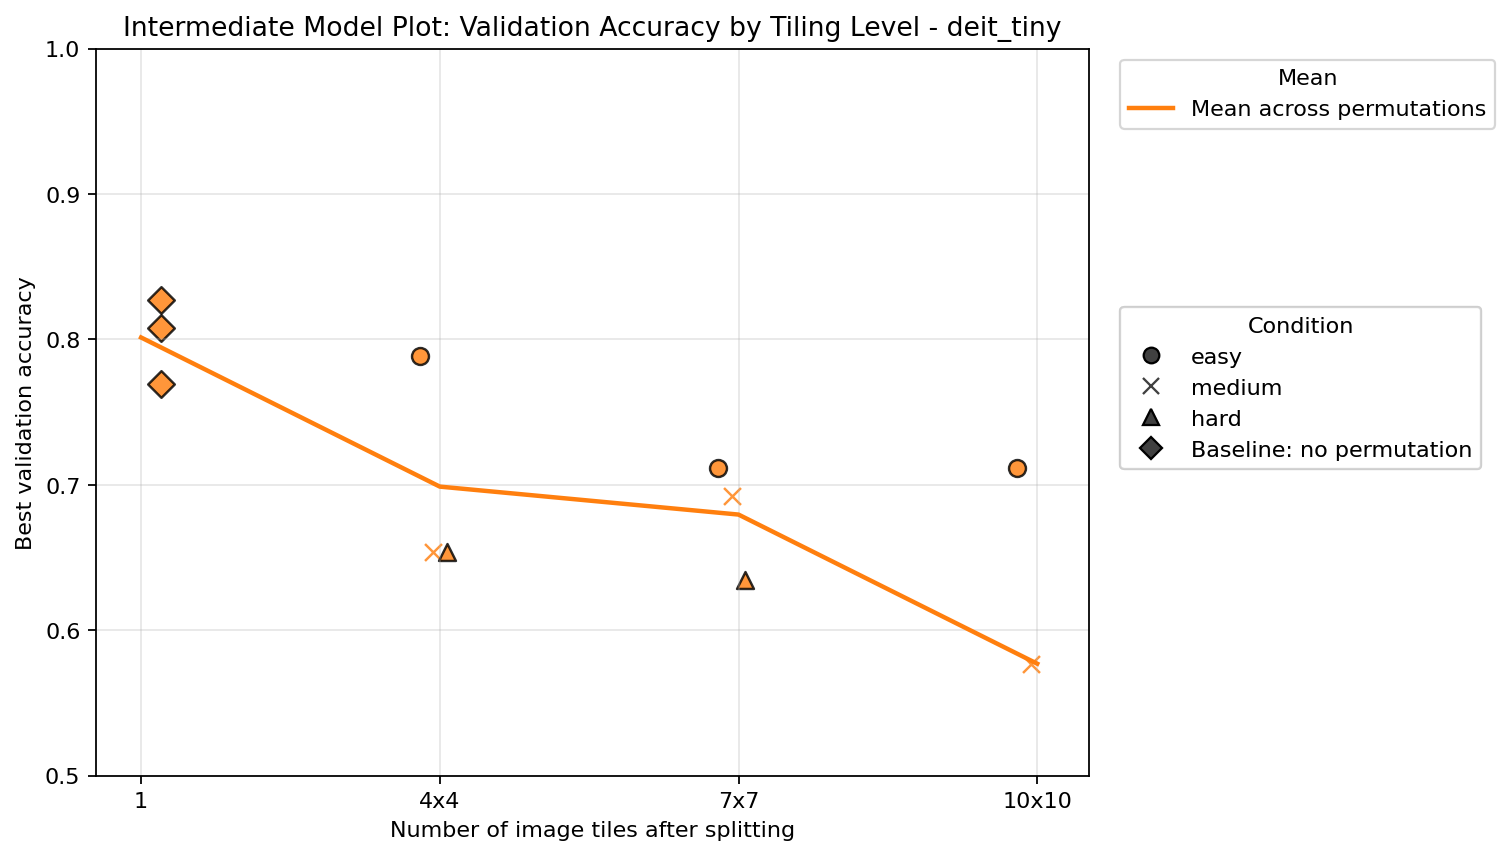

Saved 12 pending row(s) for model 'mlp_mixer_base'.

[1/12]
model=mlp_mixer_base, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'mlp_mixer_base'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=mlp_mixer_base, total_params=59,113,010, trainable_params=1,538, optimizer_params=1,538, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


mlp_mixer_base 1x1 easy permutation: 100%|██████████| 1/1 [01:28<00:00, 88.17s/epoch, best_val_accuracy=0.962, stage=standard, train_accuracy=0.931, train_loss=0.563, val_accuracy=0.962, val_loss=0.406]


Current run runtime: 3m 25s
Total training runtime: 3m 25s

[2/12]
model=mlp_mixer_base, tiles_per_side=None, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'mlp_mixer_base'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=mlp_mixer_base, total_params=59,113,010, trainable_params=1,538, optimizer_params=1,538, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


mlp_mixer_base 1x1 medium permutation: 100%|██████████| 1/1 [01:26<00:00, 86.22s/epoch, best_val_accuracy=0.981, stage=standard, train_accuracy=0.794, train_loss=0.572, val_accuracy=0.981, val_loss=0.416]


Current run runtime: 1m 35s
Total training runtime: 5m 21s

[3/12]
model=mlp_mixer_base, tiles_per_side=None, tile_permutation_id=3, tile_permutation_name=hard, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'mlp_mixer_base'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=mlp_mixer_base, total_params=59,113,010, trainable_params=1,538, optimizer_params=1,538, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


...

Current run runtime: 1m 36s
Total training runtime: 20m 48s

[11/12]
model=mlp_mixer_base, tiles_per_side=10, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'mlp_mixer_base'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=mlp_mixer_base, total_params=59,113,010, trainable_params=1,538, optimizer_params=1,538, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


mlp_mixer_base 10x10 medium permutation: 100%|██████████| 1/1 [01:29<00:00, 89.17s/epoch, best_val_accuracy=0.865, stage=standard, train_accuracy=0.603, train_loss=0.671, val_accuracy=0.865, val_loss=0.596]


Current run runtime: 1m 39s
Total training runtime: 22m 46s

[12/12]
model=mlp_mixer_base, tiles_per_side=10, tile_permutation_id=3, tile_permutation_name=hard, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'mlp_mixer_base'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=mlp_mixer_base, total_params=59,113,010, trainable_params=1,538, optimizer_params=1,538, freeze_backbone=True
First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


mlp_mixer_base 10x10 hard permutation: 100%|██████████| 1/1 [01:34<00:00, 94.06s/epoch, best_val_accuracy=0.692, stage=standard, train_accuracy=0.578, train_loss=0.685, val_accuracy=0.692, val_loss=0.627]


Current run runtime: 1m 52s
Total training runtime: 24m 59s
Saved intermediate model plot: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/intermediate/part1_accuracy_vs_tiles_mlp_mixer_base.png
Completed training mlp_mixer_base with 12 runs


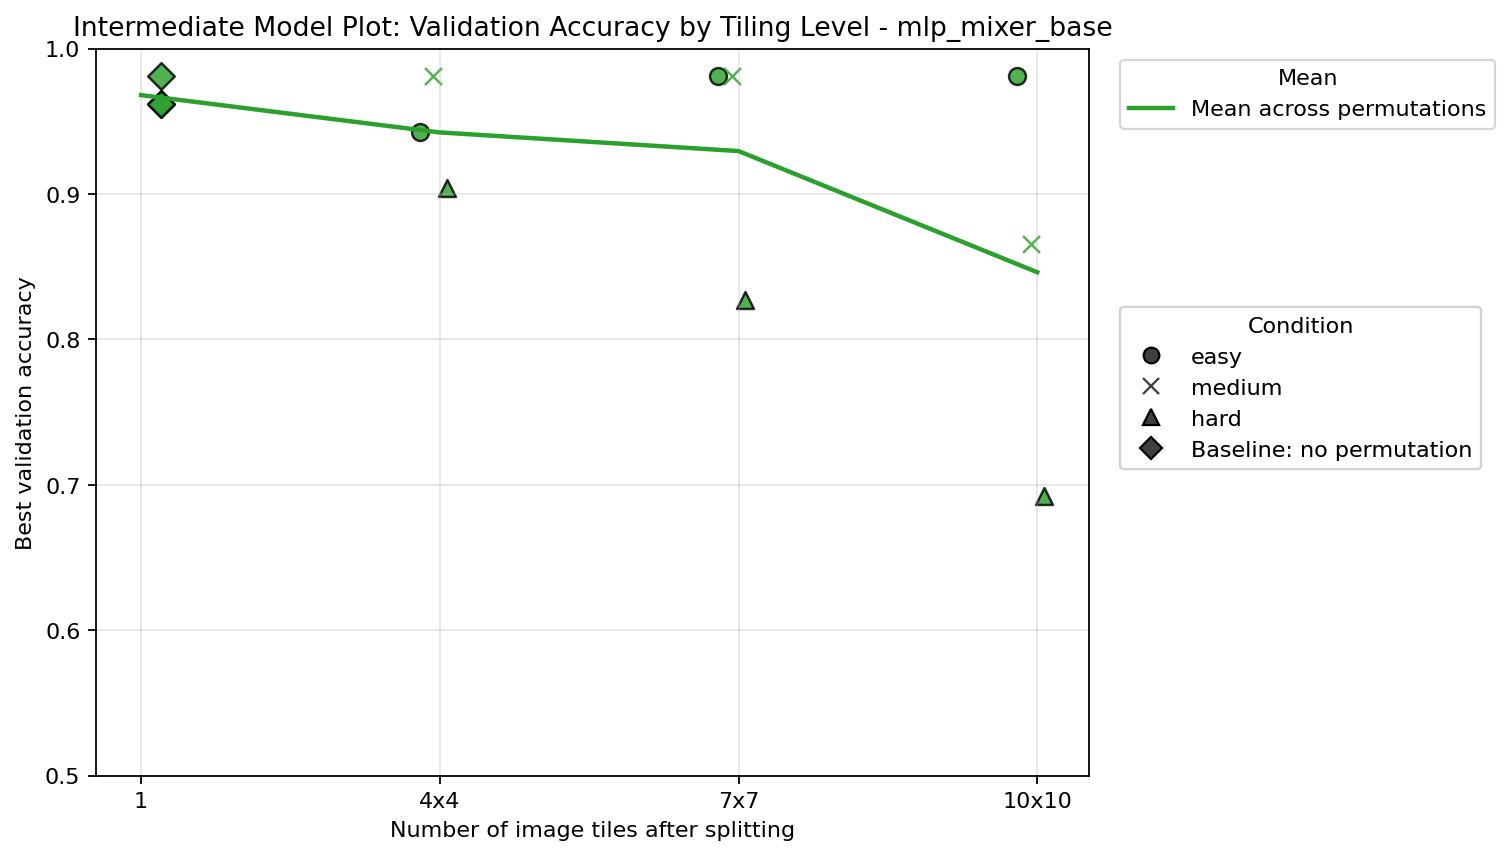

In [16]:
for model_name in configs.model_names:
    intermediate_figure_path = experiment_intermediate_figure_path(
        configs.figures_dir,
        configs.part,
        f'accuracy_vs_tiles_{model_name}',
    )
    rows = train_model_on_tile_permutation_records(
        config=configs,
        model_name=model_name,
        run_id=run_id,
        train_samples=train_samples,
        validation_samples=validation_samples,
        tile_permutation_records=tile_permutation_records,
        seed=seed,
        device=device,
        raw_results_output_path=output_paths["raw_results"],
        intermediate_figure_output_path=intermediate_figure_path,
    )
    all_rows.extend(rows)
    print("Completed training", model_name, "with", len(rows), "runs")
    if Path(intermediate_figure_path).exists():
        display(Image(filename=intermediate_figure_path))


In [17]:
# Aggregate results and plot
raw_results = pd.read_csv(filepath_or_buffer=output_paths['raw_results'])
aggregated_results = save_aggregated_accuracy(
    raw_results=raw_results,
    group_columns=['model_name', 'tiles_per_side', 'num_tiles'],
    output_path=output_paths['aggregated_results'],
)
plot_accuracy_vs_tiles(
    aggregated=aggregated_results,
    output_path=output_paths['accuracy_plot'],
    raw_results=raw_results,
)
aggregated_results

,model_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,deit_tiny,4.0,16,0.698718,0.077720,0.698718,0.077720,3
1,deit_tiny,7.0,49,0.679487,0.040032,0.679487,0.040032,3
2,deit_tiny,10.0,100,0.576923,0.134615,0.576923,0.134615,3
3,deit_tiny,NaN,1,0.801282,0.029375,0.801282,0.029375,3
4,mlp_mixer_base,4.0,16,0.942308,0.038462,0.942308,0.038462,3
5,mlp_mixer_base,7.0,49,0.929487,0.088823,0.929487,0.088823,3
6,mlp_mixer_base,10.0,100,0.846154,0.145189,0.846154,0.145189,3
7,mlp_mixer_base,NaN,1,0.967949,0.011103,0.967949,0.011103,3
8,resnet18,4.0,16,0.641026,0.072807,0.641026,0.072807,3
9,resnet18,7.0,49,0.628205,0.098685,0.628205,0.098685,3


### Experiments - Results Table
Reload the saved aggregated CSV so the report is reproducible from disk. Each row averages all tile permutation scores for the same model and tile count.


In [18]:
saved_results = {
    'raw': pd.read_csv(filepath_or_buffer=output_paths['raw_results']),
    'aggregated': pd.read_csv(filepath_or_buffer=output_paths['aggregated_results']),
}
display(saved_results['aggregated'])

,model_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,deit_tiny,4.0,16,0.698718,0.077720,0.698718,0.077720,3
1,deit_tiny,7.0,49,0.679487,0.040032,0.679487,0.040032,3
2,deit_tiny,10.0,100,0.576923,0.134615,0.576923,0.134615,3
3,deit_tiny,NaN,1,0.801282,0.029375,0.801282,0.029375,3
4,mlp_mixer_base,4.0,16,0.942308,0.038462,0.942308,0.038462,3
5,mlp_mixer_base,7.0,49,0.929487,0.088823,0.929487,0.088823,3
6,mlp_mixer_base,10.0,100,0.846154,0.145189,0.846154,0.145189,3
7,mlp_mixer_base,NaN,1,0.967949,0.011103,0.967949,0.011103,3
8,resnet18,4.0,16,0.641026,0.072807,0.641026,0.072807,3
9,resnet18,7.0,49,0.628205,0.098685,0.628205,0.098685,3


### Experiments - Accuracy Plot
Display the saved accuracy-vs-number-of-tiles plot.


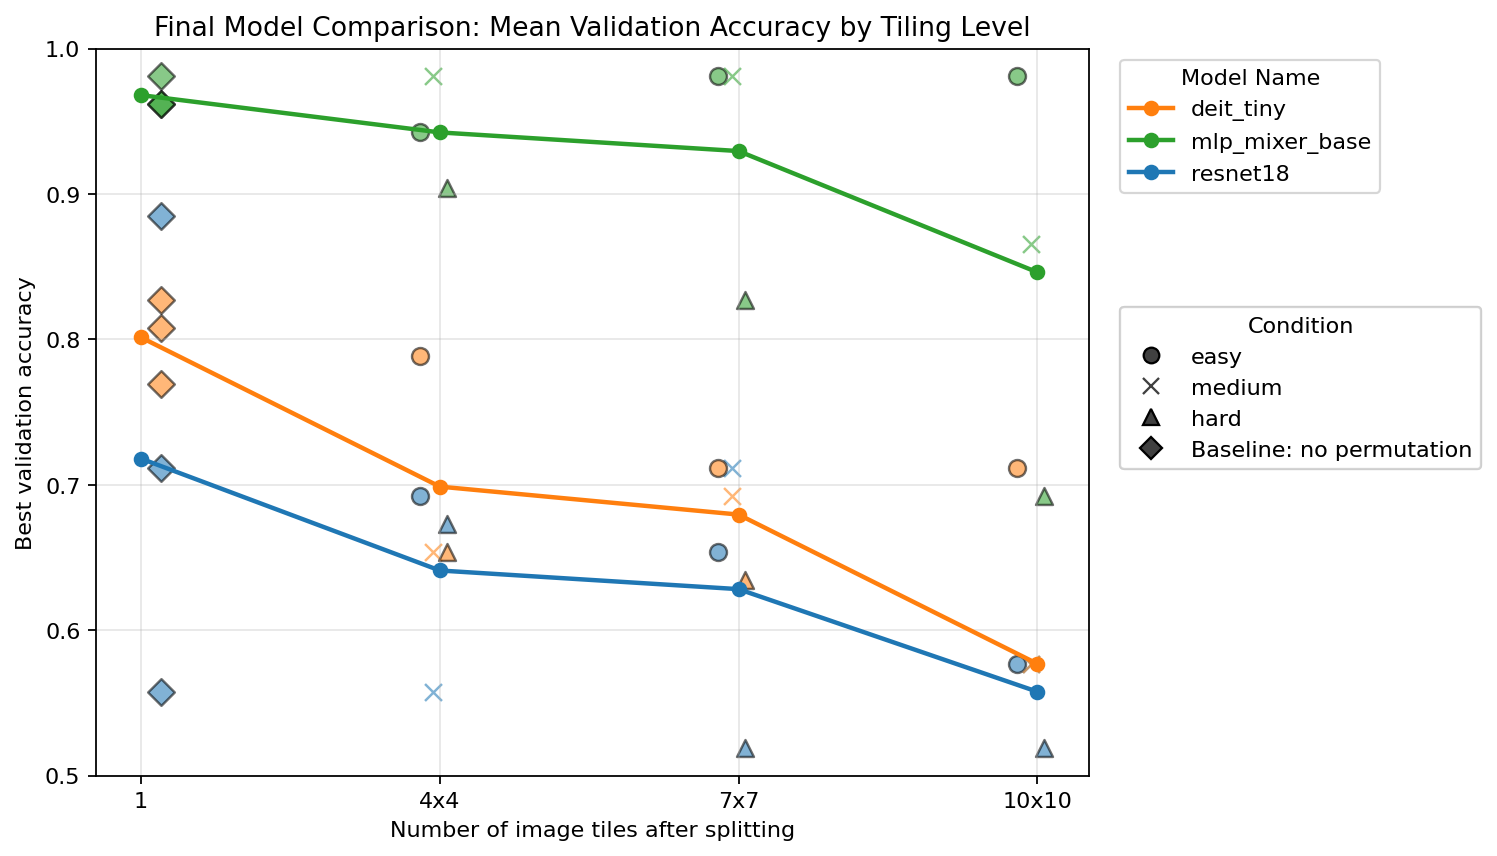

In [19]:
figure_path = output_paths['accuracy_plot']
if Path(figure_path).exists():
    display(Image(filename=figure_path))
else:
    print(f'Plot not found yet: {figure_path}')


In [20]:
# Export this saved notebook to PDF. Save the notebook before running this cell,
# because nbconvert reads the on-disk .ipynb file rather than unsaved editor state.
import importlib

import src.utils.notebook_setup as notebook_setup

notebook_setup = importlib.reload(notebook_setup)
notebook_path = ROOT / 'src' / 'notebooks' / 'part1_solution.ipynb'
export_dir = ROOT / 'outputs' / 'notebooks'
notebook_setup.export_notebook_to_pdf(notebook_path, export_dir)


Generated PDF: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/notebooks/part1_solution.pdf


PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/notebooks/part1_solution.pdf')